## Task 1.A  -  Exploratory Data Analysis

In [1]:
# First necessary inputs
import os
import sys
import pandas as pd
import numpy as np

#### Different type of samples:

- `Blank samples`: No biological information, used to assess contaminants. Consider the Zero, Solvant and Blank samples of the schema.
- `System Suitability (SS)`: Contains exogenous standards for monitoring detector behavior. Consider the SSS and SS Conditionnig samples of the schema. Experimental_blank is considered as a SS sample.
- `Disease/Control samples`: Main samples of interest, in the schema shown as RM and SRM.
- `Quality Checks (QC or dQC)`: Mixture of all samples to monitor signal consistency. Pooled QC in the schema. dQC is a diluted version of the QC and can also be considered a normal QC

#### Import the exogenous standards

In [2]:
# import csv files as dataframes

data_path = "..\data\input"
df_ex_std = pd.read_csv(os.path.join(data_path,'exogenous_standards.csv'))

# Display the first few rows of the DataFrame
df_ex_std.head()

,compound_id,mz,Retention_time
0,GU4,886.40,610
1,GU5,1048.45,753
2,GU14,1253.96,1500
3,GU15,1334.99,1551


The exogenous standards are samples run to monitor the intrument's behaviour. For each one of them we will expect this mass to charge ratio and retention time. 

They are identified by GUn corresponding to the glycan unit

#### Import the data matrix

In [3]:
df_data_mat = pd.read_csv(os.path.join(data_path,'internship_data_matrix.csv'))

# Display the first few rows of the DataFrame
df_data_mat.head

<bound method NDFrame.head of                   sample       FT-000       FT-001     FT-002       FT-003  \
0    20241106-297-Blank1     0.000000     0.000000   0.000000     0.000000   
1    20241106-297-Blank2     0.000000     0.000000   0.000000     5.770641   
2    20241106-297-Blank3     0.000000     0.000000   0.000000     0.000000   
3    20241106-297-Blank4     0.000000     5.497865   0.000000     0.000000   
4    20241106-297-Blank5     0.000000     0.000000   0.000000     0.000000   
..                   ...          ...          ...        ...          ...   
119     20241113-300-QC5   996.209869   720.286706  38.881401  2208.747760   
120     20241113-300-QC6  1942.895671  2764.681073  25.908065  4870.323716   
121     20241113-300-QC7   269.836511   153.647364  27.933945   694.930709   
122     20241113-300-QC8   723.773768   775.060757   0.000000  5492.381319   
123     20241113-300-QC9   635.820697  3057.637208   0.000000  3053.316807   

        FT-004  FT-005  FT-006   

Here the data represents for each sample the quantitative value (peak area) for each of the features, which are molecules/components of the sample.

I guess for this first part the idea is to find out which of those features are important to the analysis of glycans for lung cancer. 

In [4]:
sample_types = df_data_mat['sample'].str.split("-").str[-1].unique()
sample_types

array(['Blank1', 'Blank2', 'Blank3', 'Blank4', 'Blank5', 'Blank6', 'QC1',
       'QC2', 'QC3', 'QC4', 'QC5', '1', '10', '11', '12', '13', '14',
       '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24',
       '25', '26', '27', '3', '4', '5', '6', '7', '8', '9',
       'Experimental_Blank', 'QC10', 'QC11', 'QC6', 'QC7', 'QC8', 'QC9',
       'Diluted_QC1', 'Diluted_QC2', 'Diluted_QC3', 'Diluted_QC4',
       'Diluted_QC5'], dtype=object)

I do not see the SS (standards) run in the sample types.

In [5]:
batches = df_data_mat['sample'].str.split("-").str[1].unique()
batches

array(['297', '300'], dtype=object)

In [6]:
dates = df_data_mat['sample'].str.split("-").str[0].unique()
dates

array(['20241106', '20241113'], dtype=object)

In [7]:
df_data_mat['sample'].str.contains('GU').any()


np.False_

#### Import the feature metadata

In [8]:
# Import the metadata for the features.
df_feat_meta = pd.read_csv(os.path.join(data_path,'internship_feature_metadata.csv'))

# Display the first few rows of the DataFrame
df_feat_meta

,feature,mz,mz max,mz min,mz std,rt,rt end,rt max,rt min,rt start,rt std
0,FT-000,359.108768,359.130591,359.090122,0.010955,543.846374,561.270879,546.697803,539.941156,528.714227,1.683901
1,FT-001,357.109546,357.130018,357.091871,0.010668,543.839157,563.021530,546.948017,540.038924,528.530311,1.662290
2,FT-002,889.649931,889.702216,889.601547,0.025552,609.099742,627.717251,611.746501,606.426553,596.789046,1.324647
3,FT-003,355.111928,355.132772,355.093653,0.010508,543.995269,566.951285,547.164503,540.681882,526.943213,1.609071
4,FT-004,888.645365,888.696941,888.600202,0.026161,609.255652,632.996442,612.008732,606.778809,595.461688,1.254684
...,...,...,...,...,...,...,...,...,...,...,...
247,FT-247,1210.823728,1210.891724,1210.766982,0.035176,886.037193,894.114049,889.331356,883.543251,881.398350,1.336007
248,FT-248,925.136196,925.183723,925.091923,0.024345,1057.851741,1064.927980,1060.490508,1055.485902,1046.123490,1.362119
249,FT-249,1069.709184,1069.780424,1069.644986,0.032195,1158.068152,1163.637293,1160.474373,1155.226101,1149.945018,1.242633
250,FT-250,1069.708344,1069.774287,1069.649218,0.030645,1173.681223,1187.769703,1175.700210,1171.363591,1163.617216,1.140141


#### Import the acquisition list

In [9]:
df_acq_list = pd.read_csv(os.path.join(data_path,'internship_acquisition_list.csv'))

# Display the first few rows of the DataFrame
df_acq_list.sort_values('order')

,sample,class,id,order,batch
0,20241106-297-Blank1,B,20241106-297-Blank1,1,1
1,20241106-297-Blank2,B,20241106-297-Blank2,2,1
2,20241106-297-Blank3,B,20241106-297-Blank3,3,1
38,20241106-297-Experimental_Blank,SS,20241106-297-Experimental_Blank,4,1
6,20241106-297-Diluted-QC1,dQC,20241106-297-Diluted-QC1,7,1
...,...,...,...,...,...
114,20241113-300-QC10,QC,20241113-300-QC10,122,2
115,20241113-300-QC11,QC,20241113-300-QC11,123,2
104,20241113-300-Blank4,B,20241113-300-Blank4,124,2
105,20241113-300-Blank5,B,20241113-300-Blank5,125,2


Here we can see the in the "class" we get the SS for standards as "experimental blank". We can then here check all the classes.

In [10]:
df_acq_list['class'].unique()

array(['B', 'dQC', 'Dunn', 'SS', 'French', 'LMU', 'QC'], dtype=object)

From the repository readme:

`Important Note`: You can consider the following class mapping for the analysis:

- French: Lung cancer
- LMU: Benign disease
- Dunn: Healthy

#### Merge tables and start analysis

In [11]:
# merging the acquisition and exp data tables to get batches, classes and data together
exp_df = df_acq_list.merge(df_data_mat, left_on='sample', right_on='sample').drop(columns = 'id').sort_values('order')
#droping id column as it is the same as sample
exp_df

,sample,class,order,batch,FT-000,FT-001,FT-002,FT-003,FT-004,FT-005,...,FT-242,FT-243,FT-244,FT-245,FT-246,FT-247,FT-248,FT-249,FT-250,FT-251
0,20241106-297-Blank1,B,1,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,20241106-297-Blank2,B,2,1,0.000000,0.000000,0.000000,5.770641,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.534493,0.000000,0.000000,0.000000
2,20241106-297-Blank3,B,3,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.469501,0.000000,0.000000,0.000000
38,20241106-297-Experimental_Blank,SS,4,1,1687.701707,2360.443792,2634.198422,4142.561088,9085.299744,49640.208086,...,0.000000,0.000000,0.000000,0.000000,86.064078,2047.135847,0.000000,0.000000,0.000000,2.670024
6,20241106-297-Diluted-QC1,dQC,7,1,1399.030351,2234.397837,2081.843031,3686.431339,7044.317405,40721.275363,...,65.429736,58.502252,641.535776,25.217837,0.000000,1587.339497,401.598503,26.081734,428.331105,63.870424
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114,20241113-300-QC10,QC,122,2,628.091142,1591.936426,0.000000,5585.268766,0.000000,0.000000,...,6.476108,6.476108,0.000000,3.426699,0.000000,0.000000,96.847572,0.000000,0.000000,0.000000
115,20241113-300-QC11,QC,123,2,842.959752,3054.175903,0.000000,5009.364269,0.000000,0.000000,...,2.619426,2.619426,0.000000,6.945237,0.000000,0.000000,56.720179,0.000000,0.000000,0.000000
104,20241113-300-Blank4,B,124,2,3.126111,174.318104,0.000000,281.826813,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
105,20241113-300-Blank5,B,125,2,30.774339,176.867087,0.000000,0.000000,0.000000,0.000000,...,0.000000,4.767099,4.429893,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [12]:
batch1_df = exp_df.loc[exp_df.batch == 1]

In [13]:
batch1_df.head(10)

,sample,class,order,batch,FT-000,FT-001,FT-002,FT-003,FT-004,FT-005,...,FT-242,FT-243,FT-244,FT-245,FT-246,FT-247,FT-248,FT-249,FT-250,FT-251
0,20241106-297-Blank1,B,1,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,20241106-297-Blank2,B,2,1,0.000000,0.000000,0.000000,5.770641,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.534493,0.000000,0.000000,0.000000
2,20241106-297-Blank3,B,3,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.469501,0.000000,0.000000,0.000000
38,20241106-297-Experimental_Blank,SS,4,1,1687.701707,2360.443792,2634.198422,4142.561088,9085.299744,49640.208086,...,0.000000,0.000000,0.000000,0.000000,86.064078,2047.135847,0.000000,0.000000,0.000000,2.670024
6,20241106-297-Diluted-QC1,dQC,7,1,1399.030351,2234.397837,2081.843031,3686.431339,7044.317405,40721.275363,...,65.429736,58.502252,641.535776,25.217837,0.000000,1587.339497,401.598503,26.081734,428.331105,63.870424
7,20241106-297-Diluted-QC2,dQC,8,1,1421.659554,2165.493736,2119.732010,3640.815214,7498.426630,41381.014453,...,75.803912,58.304733,757.692671,37.094034,0.000000,1762.655206,486.387939,32.405865,600.518429,0.000000
8,20241106-297-Diluted-QC3,dQC,9,1,1490.939447,2167.935040,559.809742,3716.471966,1839.149062,13089.714518,...,93.907909,90.051001,709.895566,63.108046,2.357303,2093.661027,470.599689,37.258958,481.160995,0.000000
9,20241106-297-Diluted-QC4,dQC,10,1,1546.950461,2057.856971,1770.333817,3231.122644,6340.197841,35954.845791,...,60.812886,110.968761,844.435996,74.010468,6.683485,1593.938447,565.760844,45.158254,605.402780,8.273432
10,20241106-297-Diluted-QC5,dQC,11,1,1422.284406,2115.100624,1807.230737,3507.778199,6163.006874,39608.741795,...,103.582489,153.514937,1123.100290,91.839208,215.139328,1735.926752,736.256011,51.953778,821.249573,0.000000
91,20241106-297-QC1,QC,12,1,1574.481201,2361.738782,1381.854379,3915.191204,5170.466682,30379.842751,...,61.314172,153.974442,757.658976,74.623207,427.776005,1820.805854,903.020739,81.418951,1019.400170,0.000000


##### Check contamination

In [14]:
# Filter only the blank samples
blank_df = exp_df.loc[exp_df['class'] == 'B']

In [15]:
# Select only numeric columns
numeric_df = blank_df.select_dtypes(include=['number'])
# Apply the condition to get rows with any value greater than 200

In [16]:
contaminations = numeric_df.loc[:, numeric_df.gt(50).any(axis=0)]
contaminations

,order,FT-001,FT-003
0,1,0.000000,0.000000
1,2,0.000000,5.770641
2,3,0.000000,0.000000
3,102,5.497865,0.000000
4,103,0.000000,0.000000
5,104,0.000000,0.000000
102,105,0.000000,38.695317
103,106,46.547885,300.318172
104,124,174.318104,281.826813
105,125,176.867087,0.000000


From this preliminar analysis we can see that contaminations from FT-001 and FT-003 appear when running blank samples, but not for every blank sample. If we consider a contamination when the peak area is above 50 (maybe too low), we can say that they have only appeared on batch 2. 

We can check to which sample they correspond, and what was run before to try to understand where they come from.

In [17]:
order_cont = [104, 105, 106, 122, 123, 124, 125, 126]
exp_filt_df = exp_df.loc[exp_df['order'].isin(order_cont)][['sample','batch', 'order','FT-001', 'FT-003']]

In [18]:
exp_filt_df

,sample,batch,order,FT-001,FT-003
5,20241106-297-Blank6,1,104,0.000000,0.000000
102,20241113-300-Blank1,2,105,0.000000,38.695317
103,20241113-300-Blank2,2,106,46.547885,300.318172
114,20241113-300-QC10,2,122,1591.936426,5585.268766
115,20241113-300-QC11,2,123,3054.175903,5009.364269
104,20241113-300-Blank4,2,124,174.318104,281.826813
105,20241113-300-Blank5,2,125,176.867087,0.000000
106,20241113-300-Blank6,2,126,128.429241,0.000000


We can conclude that all contaminations are in batch2, on Blank samples 4,5,6 they could be explained by the previous QC samples, but for Blank 2 it might be just a problem with the sample. 

Anyway the contaminations are not consistent, which means that the equipment is probably not problematic for this analysis. Furthermore, batch 1 is clean and it is the one containing the experiment samples.

#### How many features have been detected, how is the distribution across mz and retention time, and across classes?

In [19]:
# Check for how many features the maximum value across samples is above 0

grouped_max = exp_df.groupby('class').max()


In [70]:
grouped_max
threshold = 500 # I have seen that for detected features the median (when not 0) is between 1000-4000

In [71]:
below_columns = pd.DataFrame(grouped_max.drop(columns = 'sample').lt(threshold).all(axis=0))
columns_below = below_columns[below_columns[0] == True].index
columns_below

Index(['order', 'batch', 'FT-047', 'FT-051', 'FT-072', 'FT-086', 'FT-115',
       'FT-116', 'FT-120', 'FT-134', 'FT-136', 'FT-144', 'FT-146', 'FT-148',
       'FT-151', 'FT-153', 'FT-174', 'FT-190', 'FT-192', 'FT-200', 'FT-201',
       'FT-202', 'FT-205', 'FT-206', 'FT-209', 'FT-215', 'FT-216', 'FT-225',
       'FT-235', 'FT-238', 'FT-239', 'FT-241', 'FT-242', 'FT-243', 'FT-245',
       'FT-249', 'FT-251'],
      dtype='object')

In [72]:
feats_real_s = grouped_max.reset_index()
feats_real_s = feats_real_s.loc[feats_real_s['class'].isin(['French', 'Dunn', 'LMU'])].drop(columns = ['sample', 'class'])
feats_real_s = feats_real_s.lt(threshold).all(axis=0)

In [73]:
# Filter for columns where all values are below threshold (True)
feats_real_s_below = feats_real_s[feats_real_s == True].index

# Further filter to get columns starting with 'FT-'
feats_real_s_below = [col for col in feats_real_s_below if col.startswith('FT-')]

# Output the result
print('The total number of features with a maximum peak area value accross trials lower than threshold is ', len(feats_real_s_below))
print(feats_real_s_below)


The total number of features with a maximum peak area value accross trials lower than threshold is  36
['FT-047', 'FT-051', 'FT-072', 'FT-086', 'FT-115', 'FT-116', 'FT-120', 'FT-132', 'FT-134', 'FT-136', 'FT-144', 'FT-146', 'FT-148', 'FT-151', 'FT-153', 'FT-174', 'FT-190', 'FT-192', 'FT-200', 'FT-201', 'FT-202', 'FT-205', 'FT-206', 'FT-209', 'FT-215', 'FT-216', 'FT-225', 'FT-235', 'FT-238', 'FT-239', 'FT-241', 'FT-242', 'FT-243', 'FT-245', 'FT-249', 'FT-251']


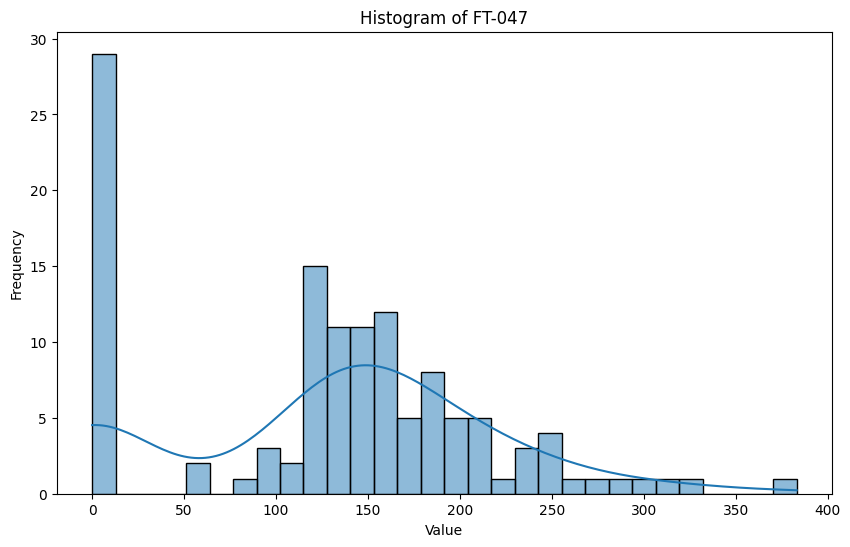

In [74]:
# Example histogram of one non-detected feature

import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'your_dataframe' is the DataFrame and 'FT-243' is the feature column
plt.figure(figsize=(10, 6))

# Using seaborn to create a histogram
sns.histplot(exp_df['FT-047'], bins=30, kde=True)

# Adding labels and title
plt.title('Histogram of FT-047')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()


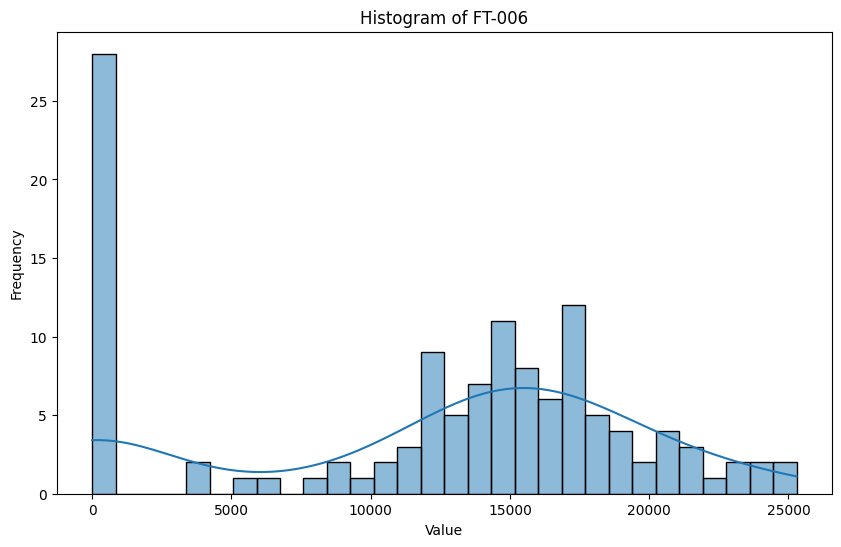

In [75]:
# Example histogram of one detected feature

import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'your_dataframe' is the DataFrame and 'FT-243' is the feature column
plt.figure(figsize=(10, 6))

# Using seaborn to create a histogram
sns.histplot(exp_df['FT-006'], bins=30, kde=True)

# Adding labels and title
plt.title('Histogram of FT-006')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()